In [1]:
# Block 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Block 2 - Create Employee Compensation Dataset
np.random.seed(42)
n = 500

# Grade structure — typical 6-level corporate hierarchy
grades = ['G1', 'G2', 'G3', 'G4', 'G5', 'G6']
grade_weights = [0.20, 0.25, 0.25, 0.15, 0.10, 0.05]

# Market midpoints by grade (AED monthly) — what the market pays at each level
market_midpoints = {
    'G1': 8000,
    'G2': 12000,
    'G3': 18000,
    'G4': 25000,
    'G5': 35000,
    'G6': 50000
}

# Pay band width — typically +/- 20% around midpoint
band_spread = 0.20

departments = ['Operations', 'Finance', 'HR', 'IT', 'Sales', 'Legal']
performance_ratings = [1, 2, 3, 4, 5]
genders = ['Male', 'Female']
nationalities = ['Emirati', 'Non-Emirati']

# Assign grades
employee_grades = np.random.choice(grades, n, p=grade_weights)

# Generate base salary with realistic variation around market midpoint
salaries = []
for grade in employee_grades:
    midpoint = market_midpoints[grade]
    # Most employees within band, some outliers
    salary = np.random.normal(midpoint, midpoint * 0.15)
    salary = max(midpoint * 0.70, min(midpoint * 1.40, salary))
    salaries.append(round(salary, -2))

df = pd.DataFrame({
    'employee_id': range(2001, 2001 + n),
    'grade': employee_grades,
    'department': np.random.choice(departments, n),
    'gender': np.random.choice(genders, n, p=[0.60, 0.40]),
    'nationality': np.random.choice(nationalities, n, p=[0.30, 0.70]),
    'years_experience': np.random.randint(1, 25, n),
    'performance_rating': np.random.choice(performance_ratings, n, p=[0.05, 0.15, 0.40, 0.30, 0.10]),
    'monthly_salary': salaries,
    'last_salary_increase_pct': np.round(np.random.uniform(0, 15, n), 1)
})

print(f"Dataset created: {df.shape[0]} employees, {df.shape[1]} columns")
print(f"\nGrade distribution:")
print(df['grade'].value_counts().sort_index())
print(f"\nSalary statistics by grade:")
print(df.groupby('grade')['monthly_salary'].agg(['mean', 'min', 'max']).round(0))

Dataset created: 500 employees, 9 columns

Grade distribution:
grade
G1    114
G2    109
G3    123
G4     71
G5     53
G6     30
Name: count, dtype: int64

Salary statistics by grade:
          mean      min      max
grade                           
G1      7812.0   5600.0  11200.0
G2     12109.0   8400.0  16600.0
G3     18173.0  12600.0  24800.0
G4     25451.0  18800.0  35000.0
G5     35058.0  25200.0  47800.0
G6     50133.0  36500.0  65500.0


In [3]:
# Block 3 - Calculate Compa-Ratio and Pay Positioning
# Add market midpoint for each employee's grade
df['market_midpoint'] = df['grade'].map(market_midpoints)

# Calculate pay band minimum and maximum
df['band_minimum'] = df['market_midpoint'] * (1 - band_spread)
df['band_maximum'] = df['market_midpoint'] * (1 + band_spread)

# Compa-ratio = actual salary / market midpoint * 100
# 100 = exactly at market midpoint
# Below 80 = significantly underpaid
# Above 120 = significantly overpaid
df['compa_ratio'] = np.round(
    (df['monthly_salary'] / df['market_midpoint']) * 100, 1
)

# Pay position category
def pay_position(row):
    if row['monthly_salary'] < row['band_minimum']:
        return 'Below Band'
    elif row['monthly_salary'] > row['band_maximum']:
        return 'Above Band'
    else:
        return 'Within Band'

df['pay_position'] = df.apply(pay_position, axis=1)

# Market percentile position
df['market_percentile'] = df.groupby('grade')['monthly_salary'].rank(pct=True).round(2) * 100

print("=== Compa-Ratio Summary by Grade ===")
print(df.groupby('grade')['compa_ratio'].agg(['mean', 'min', 'max']).round(1))

print("\n=== Pay Position Distribution ===")
print(df['pay_position'].value_counts())

print("\n=== Pay Position by Grade ===")
print(pd.crosstab(df['grade'], df['pay_position']))

=== Compa-Ratio Summary by Grade ===
        mean   min    max
grade                    
G1      97.7  70.0  140.0
G2     100.9  70.0  138.3
G3     101.0  70.0  137.8
G4     101.8  75.2  140.0
G5     100.2  72.0  136.6
G6     100.3  73.0  131.0

=== Pay Position Distribution ===
pay_position
Within Band    402
Above Band      54
Below Band      44
Name: count, dtype: int64

=== Pay Position by Grade ===
pay_position  Above Band  Below Band  Within Band
grade                                            
G1                     7          16           91
G2                    11           6           92
G3                    12           6          105
G4                    10           6           55
G5                     9           7           37
G6                     5           3           22


In [4]:
# Block 4 - Flight Risk and Gender Pay Analysis

# Flight risk flag — underpaid AND low compa-ratio
df['flight_risk_pay'] = (
    (df['compa_ratio'] < 90) | 
    (df['pay_position'] == 'Below Band')
).astype(int)

# Gender pay gap analysis by grade
gender_pay = df.groupby(['grade', 'gender'])['compa_ratio'].mean().round(1).unstack()
gender_pay['gap_pct'] = (
    (gender_pay['Male'] - gender_pay['Female']) / gender_pay['Male'] * 100
).round(1)

print("=== Flight Risk Due to Pay ===")
print(f"Total employees flagged as pay-related flight risk: {df['flight_risk_pay'].sum()}")
print(f"\nFlight risk by grade:")
print(df.groupby('grade')['flight_risk_pay'].sum())

print("\n=== Gender Pay Gap by Grade (Compa-Ratio) ===")
print(gender_pay)

print("\n=== Average Compa-Ratio by Department ===")
dept_comp = df.groupby('department')['compa_ratio'].mean().round(1).sort_values()
print(dept_comp)

print("\n=== Employees Not Reviewed (Last Increase < 3%) by Grade ===")
not_reviewed = df[df['last_salary_increase_pct'] < 3.0]
print(not_reviewed.groupby('grade').size())
print(f"\nTotal employees with minimal last increase: {len(not_reviewed)}")

=== Flight Risk Due to Pay ===
Total employees flagged as pay-related flight risk: 123

Flight risk by grade:
grade
G1    35
G2    22
G3    24
G4    15
G5    19
G6     8
Name: flight_risk_pay, dtype: int64

=== Gender Pay Gap by Grade (Compa-Ratio) ===
gender  Female   Male  gap_pct
grade                         
G1        98.7   97.2     -1.5
G2        99.9  101.6      1.7
G3        98.7  102.7      3.9
G4        99.8  103.7      3.8
G5       101.4   99.8     -1.6
G6       101.9   99.0     -2.9

=== Average Compa-Ratio by Department ===
department
Finance        97.9
IT             99.0
Operations    100.5
HR            100.7
Sales         101.2
Legal         102.0
Name: compa_ratio, dtype: float64

=== Employees Not Reviewed (Last Increase < 3%) by Grade ===
grade
G1    20
G2    21
G3    19
G4    16
G5     5
G6     4
dtype: int64

Total employees with minimal last increase: 85


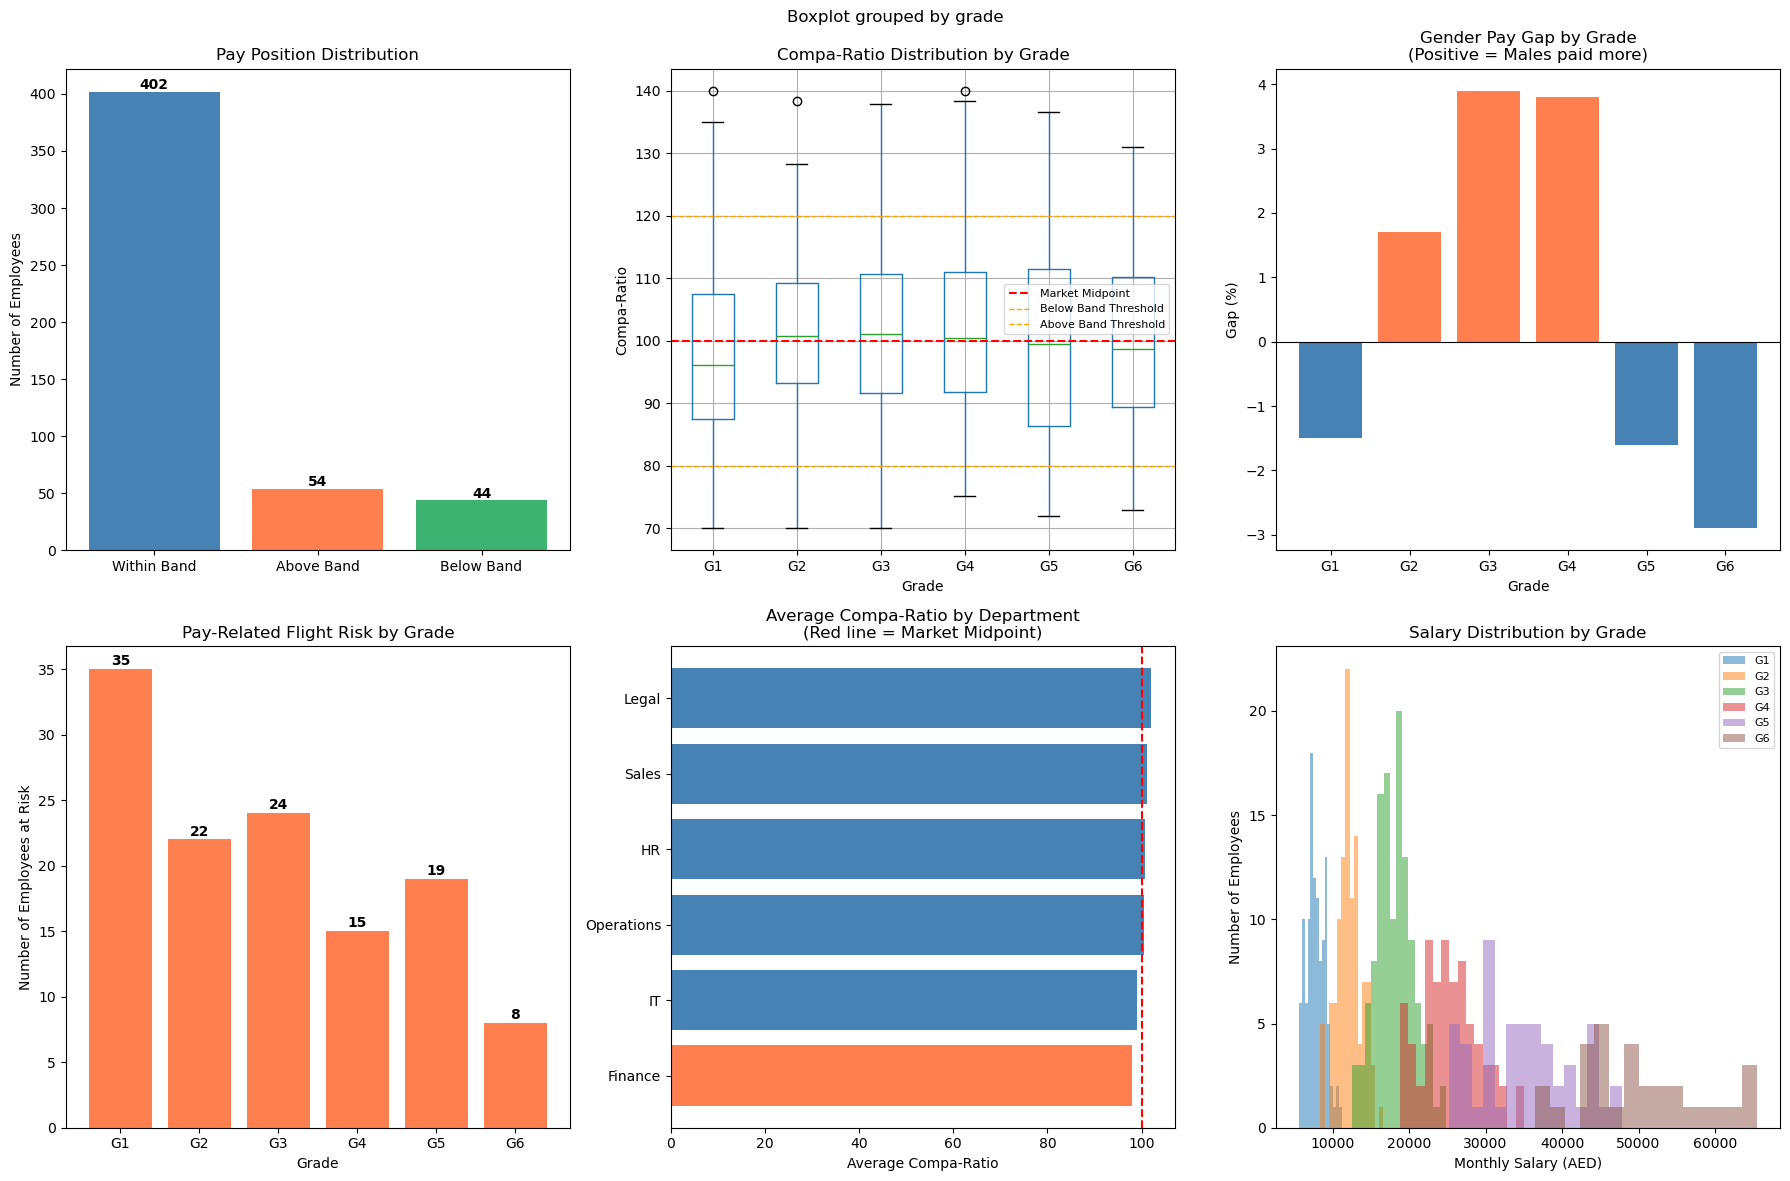

Dashboard saved as compensation_dashboard.png


In [5]:
# Block 5 - Compensation Benchmarking Dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('HR Compensation Benchmarking Dashboard', fontsize=16, fontweight='bold')

# Chart 1 - Pay Position Distribution
pay_counts = df['pay_position'].value_counts()
colors = ['mediumseagreen', 'coral', 'steelblue']
axes[0,0].bar(pay_counts.index, pay_counts.values, 
              color=['steelblue', 'coral', 'mediumseagreen'])
axes[0,0].set_title('Pay Position Distribution')
axes[0,0].set_ylabel('Number of Employees')
for i, v in enumerate(pay_counts.values):
    axes[0,0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Chart 2 - Compa-Ratio Distribution by Grade
df.boxplot(column='compa_ratio', by='grade', ax=axes[0,1])
axes[0,1].axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Market Midpoint')
axes[0,1].axhline(y=80, color='orange', linestyle='--', linewidth=1, label='Below Band Threshold')
axes[0,1].axhline(y=120, color='orange', linestyle='--', linewidth=1, label='Above Band Threshold')
axes[0,1].set_title('Compa-Ratio Distribution by Grade')
axes[0,1].set_xlabel('Grade')
axes[0,1].set_ylabel('Compa-Ratio')
axes[0,1].legend(fontsize=8)

# Chart 3 - Gender Pay Gap by Grade
gender_gap = gender_pay['gap_pct']
colors_gap = ['coral' if x > 0 else 'steelblue' for x in gender_gap.values]
axes[0,2].bar(gender_gap.index, gender_gap.values, color=colors_gap)
axes[0,2].axhline(y=0, color='black', linewidth=0.8)
axes[0,2].set_title('Gender Pay Gap by Grade\n(Positive = Males paid more)')
axes[0,2].set_xlabel('Grade')
axes[0,2].set_ylabel('Gap (%)')

# Chart 4 - Flight Risk by Grade
flight_by_grade = df.groupby('grade')['flight_risk_pay'].sum()
axes[1,0].bar(flight_by_grade.index, flight_by_grade.values, color='coral')
axes[1,0].set_title('Pay-Related Flight Risk by Grade')
axes[1,0].set_xlabel('Grade')
axes[1,0].set_ylabel('Number of Employees at Risk')
for i, v in enumerate(flight_by_grade.values):
    axes[1,0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Chart 5 - Average Compa-Ratio by Department
dept_comp_sorted = df.groupby('department')['compa_ratio'].mean().sort_values()
colors_dept = ['coral' if x < 99 else 'steelblue' for x in dept_comp_sorted.values]
axes[1,1].barh(dept_comp_sorted.index, dept_comp_sorted.values, color=colors_dept)
axes[1,1].axvline(x=100, color='red', linestyle='--', linewidth=1.5)
axes[1,1].set_title('Average Compa-Ratio by Department\n(Red line = Market Midpoint)')
axes[1,1].set_xlabel('Average Compa-Ratio')

# Chart 6 - Salary Distribution by Grade
for grade in grades:
    grade_data = df[df['grade'] == grade]['monthly_salary']
    axes[1,2].hist(grade_data, bins=15, alpha=0.5, label=grade)
axes[1,2].set_title('Salary Distribution by Grade')
axes[1,2].set_xlabel('Monthly Salary (AED)')
axes[1,2].set_ylabel('Number of Employees')
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('compensation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as compensation_dashboard.png")

In [6]:
# Block 6 - Generate Compensation Action Report
# Full employee level output with recommendations
output = df[[
    'employee_id', 'grade', 'department', 'gender', 'nationality',
    'years_experience', 'performance_rating', 'monthly_salary',
    'market_midpoint', 'band_minimum', 'band_maximum',
    'compa_ratio', 'pay_position', 'market_percentile',
    'flight_risk_pay', 'last_salary_increase_pct'
]].copy()

# Recommended action based on pay position and performance
def recommend_action(row):
    if row['pay_position'] == 'Below Band':
        if row['performance_rating'] >= 3:
            return 'Immediate Review — Below Band, Performing'
        else:
            return 'Monitor — Below Band, Low Performance'
    elif row['pay_position'] == 'Above Band':
        if row['performance_rating'] >= 4:
            return 'Grade Progression Review'
        else:
            return 'Salary Freeze — Above Band'
    else:
        if row['compa_ratio'] < 90 and row['performance_rating'] >= 4:
            return 'Priority Increase — Low Compa, High Performer'
        elif row['compa_ratio'] > 110 and row['performance_rating'] <= 2:
            return 'Salary Freeze — High Compa, Low Performer'
        else:
            return 'No Action Required'

output['recommended_action'] = output.apply(recommend_action, axis=1)

# Cost to bring below-band employees to band minimum
output['cost_to_minimum'] = output.apply(
    lambda row: max(0, row['band_minimum'] - row['monthly_salary']), axis=1
).round(0)

# Summary
print("=== Compensation Action Summary ===")
print(output['recommended_action'].value_counts())

print(f"\n=== Cost to Fix Below Band Employees ===")
below_band_cost = output[output['pay_position'] == 'Below Band']['cost_to_minimum'].sum()
print(f"Monthly cost to bring all below-band to minimum: AED {below_band_cost:,.0f}")
print(f"Annual cost:                                     AED {below_band_cost * 12:,.0f}")

print(f"\n=== Priority Actions ===")
priority = output[output['recommended_action'].str.contains('Immediate|Priority')]
print(f"Employees needing immediate or priority action: {len(priority)}")
print(f"\nTop 10 priority employees (lowest compa-ratio, performing):")
print(priority.nsmallest(10, 'compa_ratio')[
    ['employee_id', 'grade', 'department', 'monthly_salary', 
     'market_midpoint', 'compa_ratio', 'recommended_action']
].to_string(index=False))

# Save output
output.to_csv('compensation_action_report.csv', index=False)
print("\nCompensation action report saved to compensation_action_report.csv")

=== Compensation Action Summary ===
recommended_action
No Action Required                               362
Immediate Review — Below Band, Performing         38
Salary Freeze — Above Band                        29
Priority Increase — Low Compa, High Performer     28
Grade Progression Review                          25
Salary Freeze — High Compa, Low Performer         12
Monitor — Below Band, Low Performance              6
Name: count, dtype: int64

=== Cost to Fix Below Band Employees ===
Monthly cost to bring all below-band to minimum: AED 40,900
Annual cost:                                     AED 490,800

=== Priority Actions ===
Employees needing immediate or priority action: 66

Top 10 priority employees (lowest compa-ratio, performing):
 employee_id grade department  monthly_salary  market_midpoint  compa_ratio                        recommended_action
        2046    G3         IT         12600.0            18000         70.0 Immediate Review — Below Band, Performing
        205